In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.isnull().sum()


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [9]:
df["Age"]=2026-df["Year_Birth"]

In [10]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

refernce_date=df["Dt_Customer"].max()

df["Customer_tenure_days"]=(refernce_date - df["Dt_Customer"]).dt.days

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days'],
      dtype='object')

In [13]:
df["Total_spendings"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days',
       'Total_spendings'],
      dtype='object')

In [15]:
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [63]:
#convert eduction into 3 categories undergraduate,graduate and post

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})

    
    

In [64]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [65]:
df["living_with"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})
    

In [66]:
df["living_with"].value_counts()

living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [67]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days',
       'Total_spendings', 'Total_children', 'living_with'],
      dtype='object')

## Drop Colums

In [68]:
cols=["ID", "Marital_Status","Kidhome","Teenhome","Year_Birth",'MntWines',"Dt_Customer", 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
df_cleaned=df.drop(columns=cols)

In [69]:
df_cleaned.shape

(2240, 15)

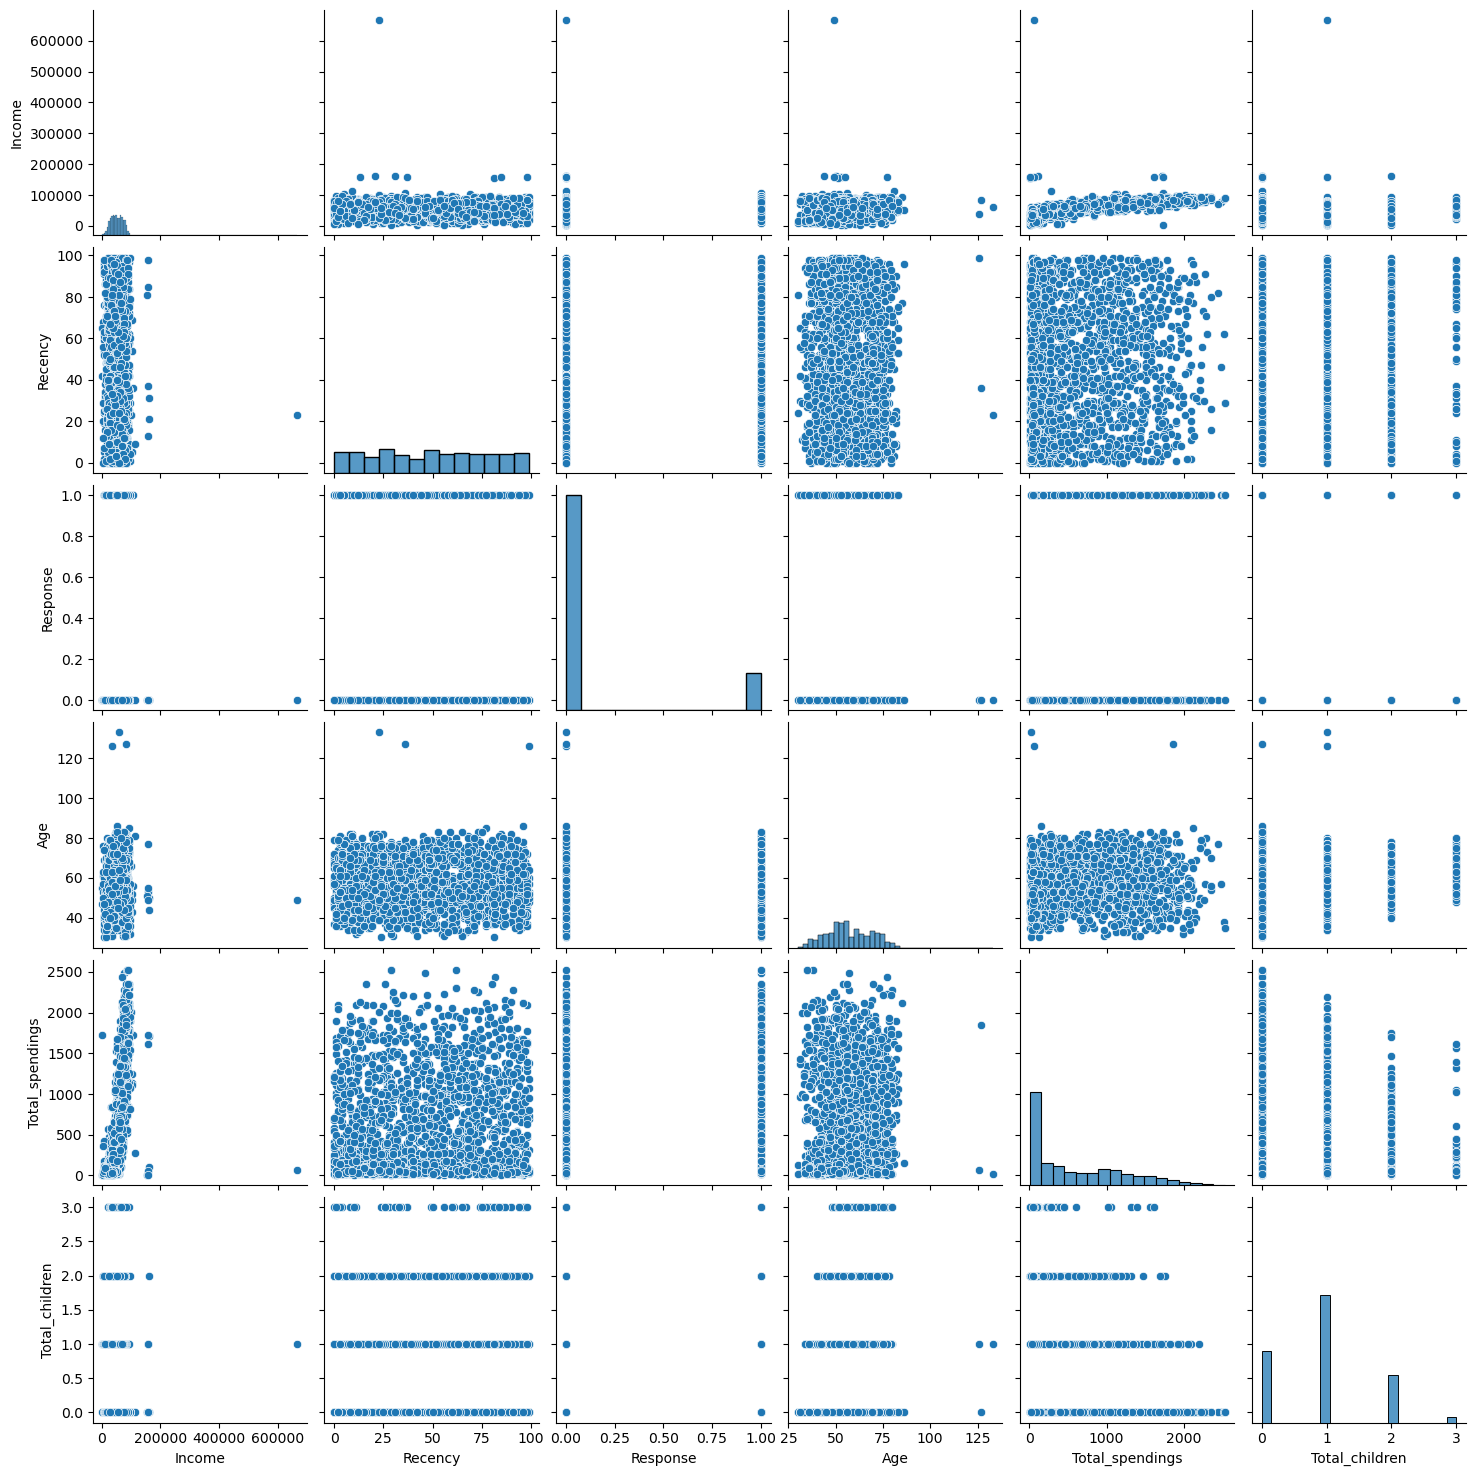

In [70]:
cols=["Income",'Recency','Response', 'Age','Total_spendings', 'Total_children']
sns.pairplot(df_cleaned[cols])

In [71]:
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600000)]

In [72]:
print(len(df_cleaned))

2236


<Axes: >

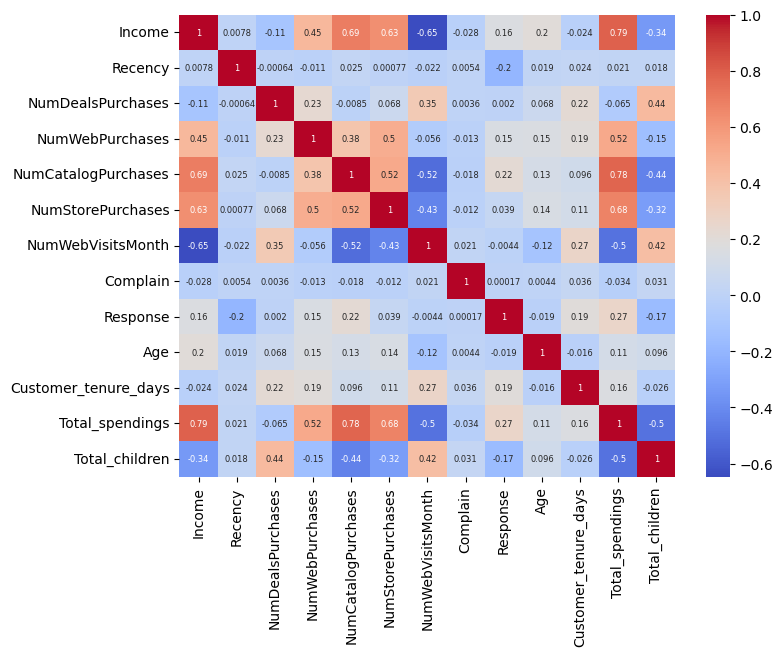

In [73]:
corr=df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

## Feature Encoding

In [74]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()

cols=['Education','living_with']
encoded_cols=ohe.fit_transform(df_cleaned[cols])


In [75]:
encoded_df=pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cols), index=df_cleaned.index)


In [76]:
encoded_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [78]:
df_encoded=pd.concat([df_cleaned.drop(columns=cols),encoded_df],axis=1)

In [79]:
df_encoded.shape

(2236, 18)

In [80]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spendings,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


  ## Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

In [84]:
X=df_encoded

In [85]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [87]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)

X_pcs=pca.fit_transform(X_scaled)

In [91]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## Choose k value

In [93]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pcs)
    wcss.append(kmeans.inertia_)

In [94]:
knee=KneeLocator(range(1,11), wcss ,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [95]:
print(optimal_k)

4


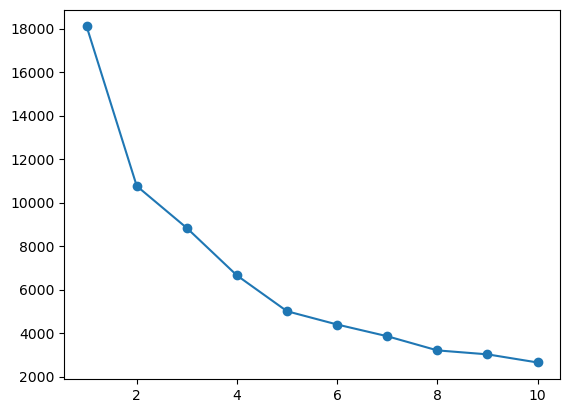

In [96]:
plt.plot(range(1,11), wcss,marker="o")

In [97]:
from sklearn.metrics import silhouette_score

In [98]:
ss=[]
for k in range (2,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X_pcs)
    score=silhouette_score(X_pcs,labels)
    ss.append(score)

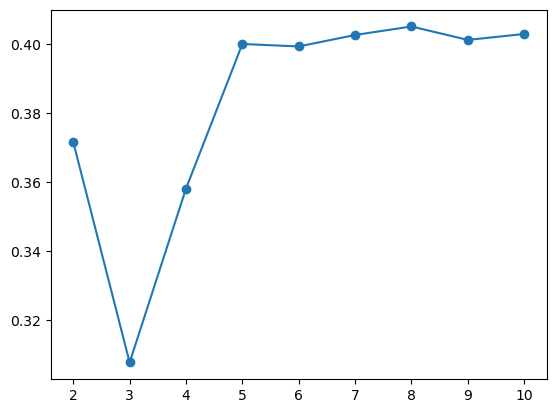

In [100]:
plt.plot(range(2,11), ss,marker="o")

## Clustering

In [102]:
kmeans=KMeans(
    n_clusters=4,random_state=42)
labels=kmeans.fit_predict(X_pcs)


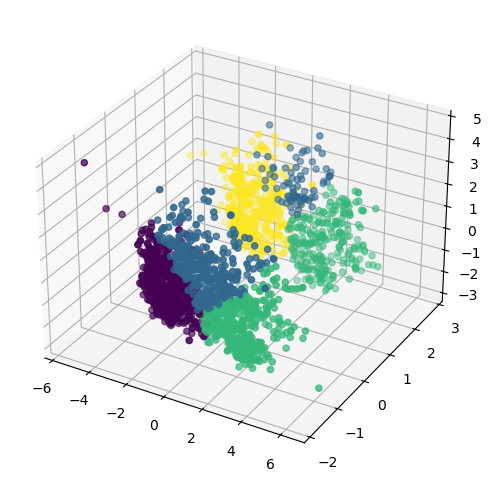

In [104]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection="3d")
ax.scatter(X_pcs[:,0],X_pcs[:,1],X_pcs[:,2],c=labels)

In [106]:
from sklearn.cluster import AgglomerativeClustering

In [108]:
agg_clu=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clu.fit_predict(X_pcs)

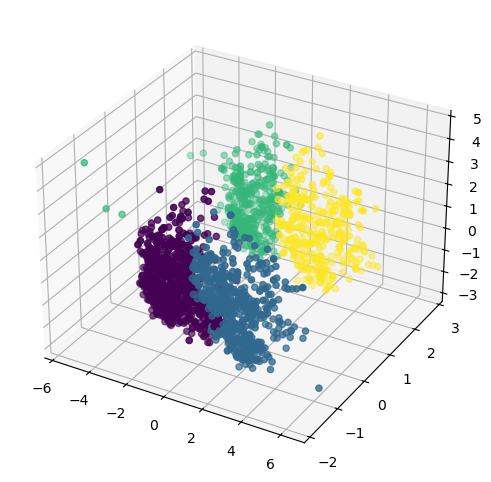

In [109]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111, projection="3d")
ax.scatter(X_pcs[:,0],X_pcs[:,1],X_pcs[:,2],c=labels_agg)

## Characterisation of clusters

In [118]:
df_cleaned["cluster"]=labels_agg

In [119]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spendings,Total_children,living_with,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='cluster', ylabel='count'>

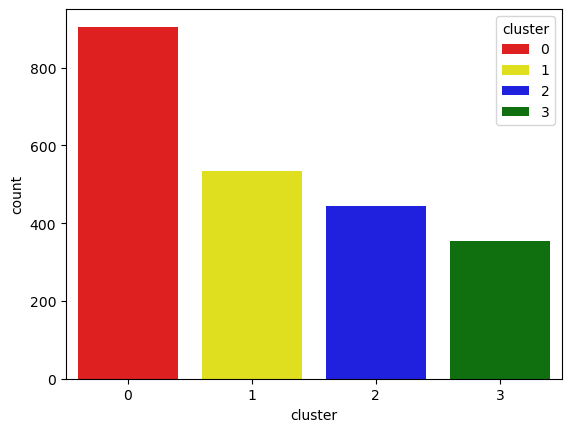

In [120]:
pal=["red","yellow","blue","green"]
sns.countplot(x=df_cleaned['cluster'],palette=pal,hue=df_cleaned['cluster'])

<Axes: xlabel='Total_spendings', ylabel='Income'>

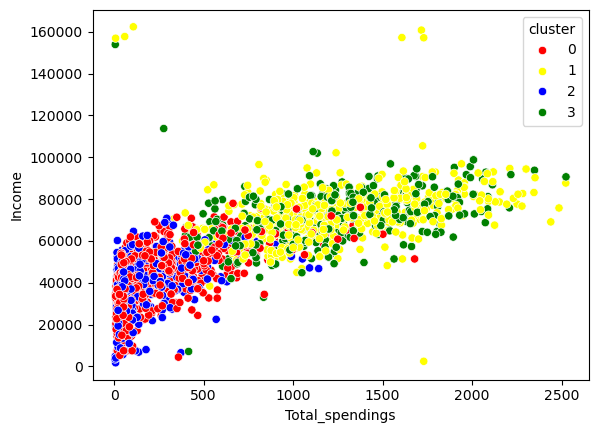

In [115]:
# Income and spending patterns

sns.scatterplot(x=df_cleaned["Total_spendings"],y=df_cleaned["Income"],hue=df_cleaned['cluster'],palette=pal)


In [116]:
#Spending is directly proportional to the income in most of the cases


In [121]:
X["cluster"]=labels_agg

In [122]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spendings,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,living_with_Alone,living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

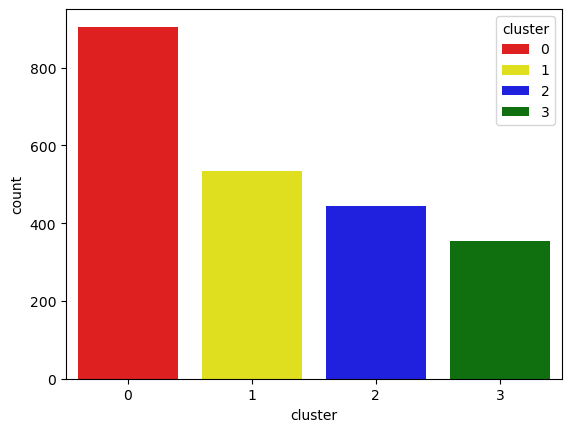

In [123]:
pal=["red","yellow","blue","green"]
sns.countplot(x=X['cluster'],palette=pal,hue=X['cluster'])

<Axes: xlabel='Total_spendings', ylabel='Income'>

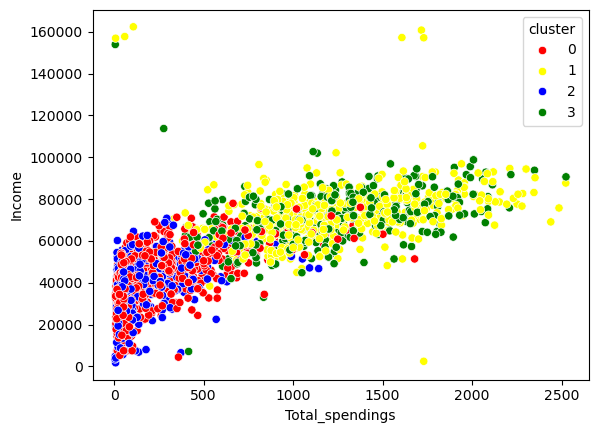

In [124]:
sns.scatterplot(x=X["Total_spendings"],y=X["Income"],hue=X['cluster'],palette=pal)

In [125]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_days  Total_spendings  \
cluster        